In [1]:
using Random, Statistics
using Colors
using Plots

default(; size=(880, 380))
ENV["GKSwstype"] = "100"

┌ Warning: attempting to remove probably stale pidfile
│   path = "C:\\Users\\User\\.julia\\compiled\\v1.11\\Plots\\ld3vC_RyqJC.ji.pidfile"
└ @ FileWatching.Pidfile C:\Users\User\.julia\juliaup\julia-1.11.6+0.x64.w64.mingw32\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:249
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (2), incompatible header (2), dep missing source (2))
┌ Warning: failed to remove pidfile on close
│   path = "C:\\Users\\User\\.julia\\compiled\\v1.11\\Plots\\ld3vC_RyqJC.ji.pidfile"
│   removed = false
└ @ FileWatching.Pidfile C:\Users\User\.julia\juliaup\julia-1.11.6+0.x64.w64.mingw32\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:347
[ Info: Precompiling GRIJuliaExt [84369c5d-ffb2-5a92-8288-3470980d96d0] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (4), incompatible header (2))


"100"

In [2]:

gray_palette() = [RGB{Float64}(t,t,t) for t in range(0, 1, length=7)]

function blue_palette()
    
    a = RGB(0.03, 0.06, 0.20)
    b = RGB(0.85, 0.92, 1.00)
    return [RGB{Float64}(a.r + (b.r-a.r)*t, a.g + (b.g-a.g)*t, a.b + (b.b-a.b)*t) for t in range(0,1,length=7)]
end

pal = blue_palette()  

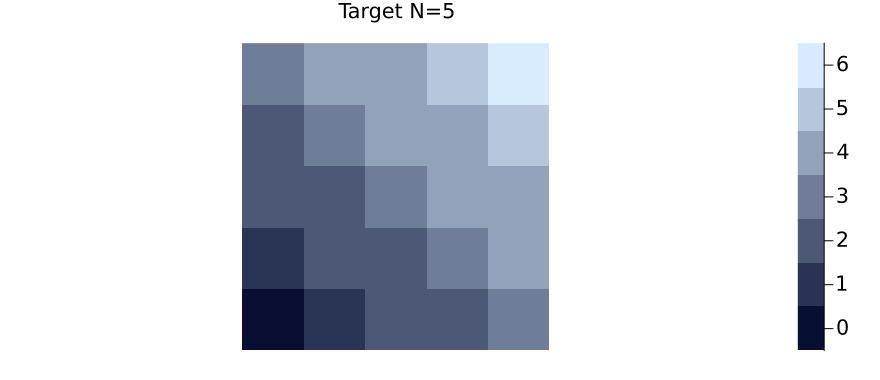

In [3]:

function make_target_ids(N::Int)
    ids = Array{Int}(undef, N, N)
    for i in 1:N, j in 1:N
        
        t = (i-1 + j-1) / max(1, 2*(N-1))
        ids[i,j] = clamp(round(Int, 6*t), 0, 6)
    end
    return vec(ids)  
end

function show_grid(ids::Vector{Int}, N::Int; title="")
    
    M = reshape(ids, N, N)
    cg = cgrad(pal, 7; categorical=true)
    heatmap(
        M;
        c=cg,
        clims=(-0.5, 6.5),
        colorbar_ticks=(0:6, string.(0:6)),
        aspect_ratio=1,
        axis=false,
        ticks=false,
        title=title,
        interpolate=false,
    )
end

target5 = make_target_ids(5)
show_grid(target5, 5; title="Target N=5")

In [4]:

const BITS_PER_GENE = 3

function ids_to_bits(ids::Vector{Int})
    bits = Vector{Bool}(undef, length(ids)*BITS_PER_GENE)
    k = 1
    @inbounds for v in ids
        x = clamp(v, 0, 6)
        bits[k]   = (x & 0x4) != 0; k += 1
        bits[k]   = (x & 0x2) != 0; k += 1
        bits[k]   = (x & 0x1) != 0; k += 1
    end
    return bits
end

function bits_to_ids(bits::Vector{Bool})
    @assert length(bits) % BITS_PER_GENE == 0
    L = length(bits) ÷ BITS_PER_GENE
    ids = Vector{Int}(undef, L)
    k = 1
    @inbounds for i in 1:L
        x = (bits[k] ? 4 : 0) + (bits[k+1] ? 2 : 0) + (bits[k+2] ? 1 : 0)
        ids[i] = min(x, 6)  
        k += 3
    end
    return ids
end

bits_to_ids (generic function with 1 method)

In [5]:

hamming(a::Vector{Bool}, b::Vector{Bool}) = sum(@inbounds a[i] != b[i] for i in eachindex(a))

function euclid(ids::Vector{Int}, target::Vector{Int})
    @assert length(ids) == length(target)
    s = 0.0
    @inbounds for i in eachindex(ids)
        d = Float64(ids[i] - target[i])
        s += d*d
    end
    return sqrt(s)
end

euclid (generic function with 1 method)

In [6]:
Base.@kwdef struct GAParams
    population_size::Int = 80
    max_generations::Int = 800
    elitism::Int = 2
    tournament_k::Int = 3
    crossover_rate::Float64 = 0.95
    mutation_p::Float64 = 0.012      
    crossover_mode::Symbol = :onepoint_bits  
    stagnation_generations::Int = 80
    immigrants_count::Int = 8
    mutation_boost::Float64 = 3.0
    seed::Int = 1
end

function tournament_select(values::Vector{Float64}, k::Int, rng::AbstractRNG)
    n = length(values)
    best = rand(rng, 1:n)
    bestv = values[best]
    for _ in 2:k
        i = rand(rng, 1:n)
        v = values[i]
        if v < bestv
            best, bestv = i, v
        end
    end
    return best
end

function one_point_crossover(a::Vector{Bool}, b::Vector{Bool}, rng::AbstractRNG)
    n = length(a)
    @assert n == length(b) && n >= 2
    cp = rand(rng, 1:(n-1))
    c1 = Vector{Bool}(undef, n)
    c2 = Vector{Bool}(undef, n)
    @inbounds begin
        for i in 1:cp
            c1[i] = a[i]
            c2[i] = b[i]
        end
        for i in (cp+1):n
            c1[i] = b[i]
            c2[i] = a[i]
        end
    end
    return c1, c2, cp
end

function uniform_genes_crossover(a::Vector{Bool}, b::Vector{Bool}, rng::AbstractRNG)
    
    @assert length(a) == length(b)
    n = length(a)
    @assert n % BITS_PER_GENE == 0
    L = n ÷ BITS_PER_GENE
    c1 = Vector{Bool}(undef, n)
    c2 = Vector{Bool}(undef, n)
    @inbounds for g in 0:(L-1)
        take_a = rand(rng, Bool)
        o = g*BITS_PER_GENE
        for j in 1:BITS_PER_GENE
            i = o + j
            c1[i] = take_a ? a[i] : b[i]
            c2[i] = take_a ? b[i] : a[i]
        end
    end
    return c1, c2
end

function mutate_bits!(x::Vector{Bool}, p::Float64, rng::AbstractRNG)
    @inbounds for i in eachindex(x)
        if rand(rng) < p
            x[i] = !x[i]
        end
    end
    return x
end

function inject_immigrants!(pop_bits::Vector{Vector{Bool}}, scores::Vector{Float64}, genome_len::Int, params::GAParams, rng::AbstractRNG)
    k = min(params.immigrants_count, length(pop_bits) - params.elitism)
    k <= 0 && return
    worst = partialsortperm(scores, (length(scores)-k+1):length(scores); rev=true)
    for idx in worst
        pop_bits[idx] = rand(rng, Bool, genome_len)
    end
end

inject_immigrants! (generic function with 1 method)

In [7]:
function run_ga(N::Int; metric::Symbol=:euclid, eps::Float64=1e-3, params=GAParams())
    rng = MersenneTwister(params.seed)

    target_ids = make_target_ids(N)
    target_bits = ids_to_bits(target_ids)

    
    pop_bits = [rand(rng, Bool, length(target_bits)) for _ in 1:params.population_size]

    function score(bits)
        if metric == :hamming
            return Float64(hamming(bits, target_bits))
        elseif metric == :euclid
            ids = bits_to_ids(bits)
            return euclid(ids, target_ids)
        else
            error("metric must be :hamming or :euclid")
        end
    end

    scores = [score(b) for b in pop_bits]
    best_hist = Float64[]
    best_ids_hist = Vector{Vector{Int}}()

    best_i = argmin(scores)
    best_bits = copy(pop_bits[best_i])
    best_score = scores[best_i]
    push!(best_hist, best_score)
    push!(best_ids_hist, bits_to_ids(best_bits))

    stop_reason = "max_generations"
    gens = 0
    no_improve = 0

    for gen in 1:params.max_generations
        gens = gen

        elite_idx = partialsortperm(scores, 1:params.elitism)
        newpop = Vector{Vector{Bool}}(undef, params.population_size)
        for (k, ei) in enumerate(elite_idx)
            newpop[k] = copy(pop_bits[ei])
        end
        pos = params.elitism + 1
        while pos <= params.population_size
            p1 = pop_bits[tournament_select(scores, params.tournament_k, rng)]
            p2 = pop_bits[tournament_select(scores, params.tournament_k, rng)]

            c1 = copy(p1)
            c2 = copy(p2)
            if rand(rng) < params.crossover_rate
                if params.crossover_mode == :onepoint_bits
                    c1, c2, _ = one_point_crossover(p1, p2, rng)
                elseif params.crossover_mode == :uniform_genes
                    c1, c2 = uniform_genes_crossover(p1, p2, rng)
                else
                    error("Unknown crossover_mode = $(params.crossover_mode)")
                end
            end

            pm = no_improve >= params.stagnation_generations ? min(0.30, params.mutation_p * params.mutation_boost) : params.mutation_p
            mutate_bits!(c1, pm, rng)
            mutate_bits!(c2, pm, rng)

            newpop[pos] = c1
            pos += 1
            if pos <= params.population_size
                newpop[pos] = c2
                pos += 1
            end
        end

        pop_bits = newpop
        scores = [score(b) for b in pop_bits]

        bi = argmin(scores)
        bv = scores[bi]
        if bv < best_score
            best_score = bv
            best_bits = copy(pop_bits[bi])
            no_improve = 0
        else
            no_improve += 1
        end

        if no_improve == params.stagnation_generations
            inject_immigrants!(pop_bits, scores, length(target_bits), params, rng)
            scores = [score(b) for b in pop_bits]
        end

        push!(best_hist, best_score)
        push!(best_ids_hist, bits_to_ids(best_bits))

        if best_score < eps
            stop_reason = "eps"
            break
        end
    end

    return (
        N=N,
        metric=metric,
        eps=eps,
        params=params,
        target_ids=target_ids,
        best_ids=bits_to_ids(best_bits),
        best_hist=best_hist,
        best_ids_hist=best_ids_hist,
        generations=gens,
        stop_reason=stop_reason,
    )
end

run_ga (generic function with 1 method)

[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N5_euclid.gif


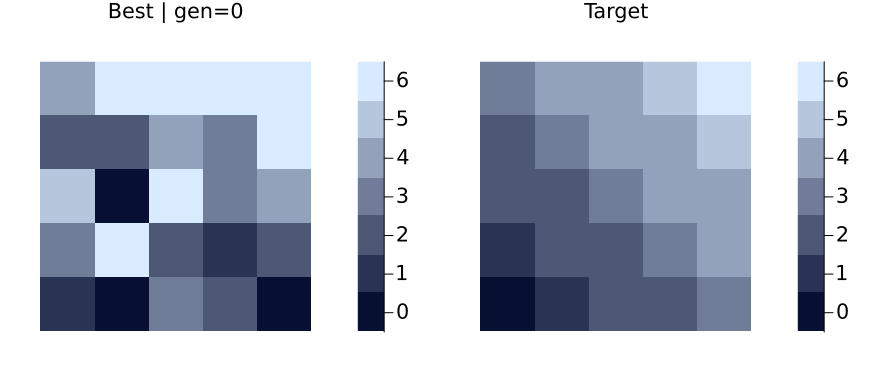

"ga_N5_euclid.gif"

In [8]:
function make_gif(result; filename::String, every::Int=1, fps::Int=12)
    N = result.N
    target = result.target_ids
    hist = result.best_ids_hist

    anim = @animate for gen in 0:every:(length(hist)-1)
        best = hist[gen+1]
        p1 = show_grid(best, N; title="Best | gen=$(gen)")
        p2 = show_grid(target, N; title="Target")
        plot(p1, p2; layout=(1,2))
    end
    gif(anim, filename; fps=fps)
    display("image/gif", read(filename))
    return filename
end


params = GAParams(population_size=90, max_generations=700, mutation_p=0.012, crossover_mode=:uniform_genes, seed=1)
res5 = run_ga(5; metric=:euclid, eps=1e-3, params=params)

make_gif(res5; filename="ga_N5_euclid.gif", every=1, fps=12)


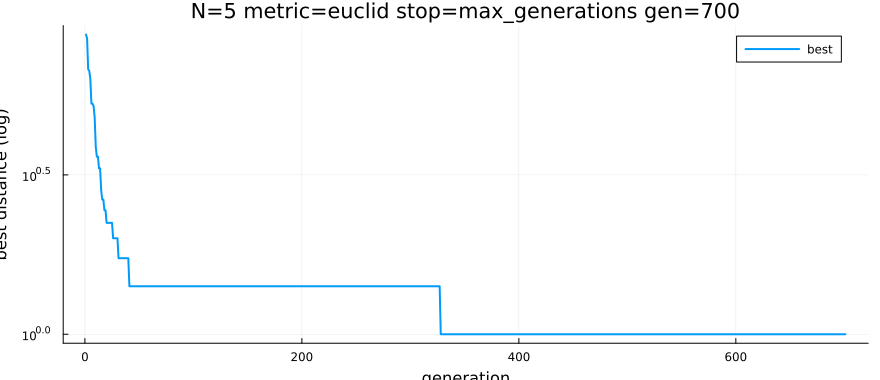

In [9]:

plot(res5.best_hist; yscale=:log10, linewidth=2, xlabel="generation", ylabel="best distance (log)",
     title="N=$(res5.N) metric=$(res5.metric) stop=$(res5.stop_reason) gen=$(res5.generations)", label="best")

[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N3_euclid_uniform_genes.gif


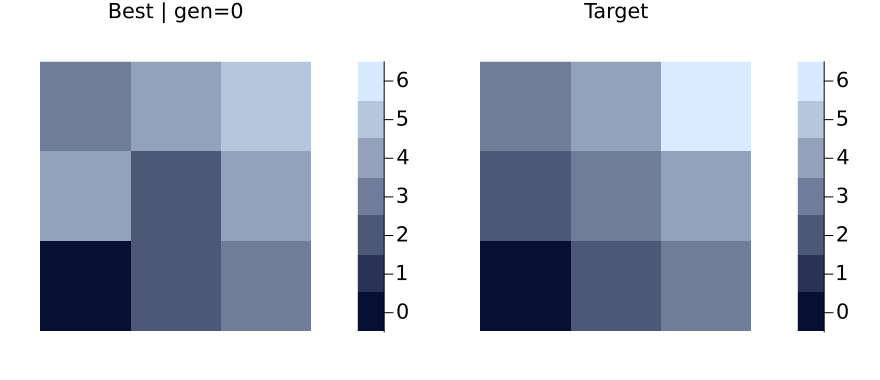

┌ Info: done
│   N = 3
│   metric = :euclid
│   crossover = :uniform_genes
│   best = 0.0
│   gen = 9
│   stop = "eps"
└   file = "ga_N3_euclid_uniform_genes.gif"
[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N3_hamming_uniform_genes.gif


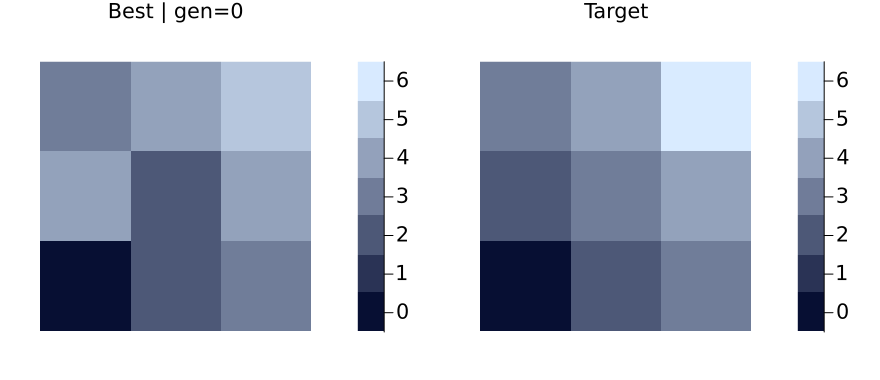

┌ Info: done
│   N = 3
│   metric = :hamming
│   crossover = :uniform_genes
│   best = 0.0
│   gen = 6
│   stop = "eps"
└   file = "ga_N3_hamming_uniform_genes.gif"
[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N5_euclid_uniform_genes.gif


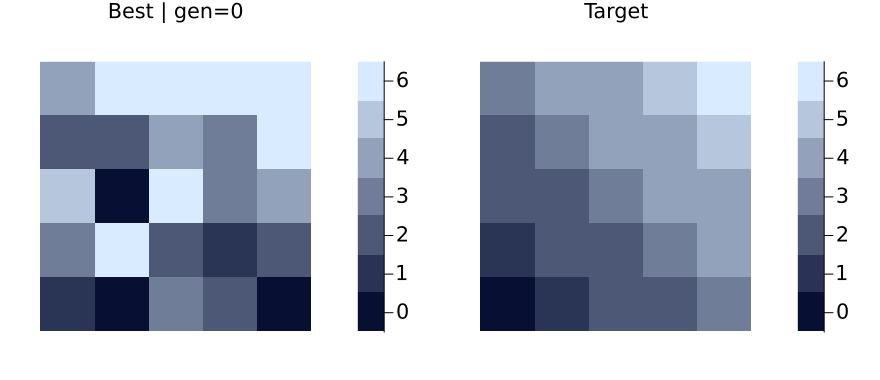

┌ Info: done
│   N = 5
│   metric = :euclid
│   crossover = :uniform_genes
│   best = 1.4142135623730951
│   gen = 650
│   stop = "max_generations"
└   file = "ga_N5_euclid_uniform_genes.gif"
[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N5_hamming_uniform_genes.gif


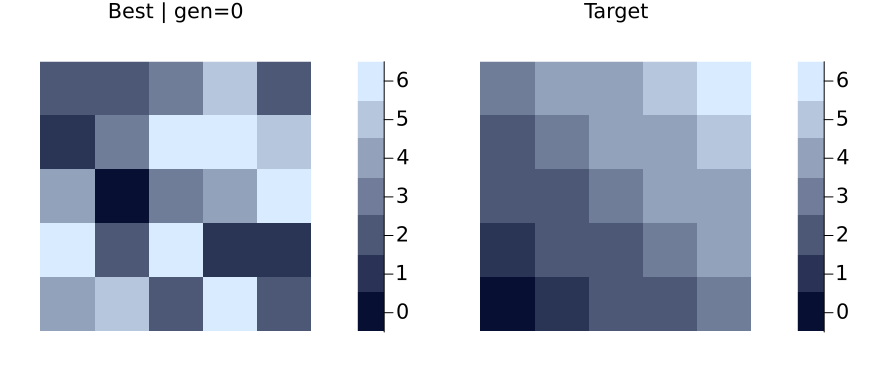

┌ Info: done
│   N = 5
│   metric = :hamming
│   crossover = :uniform_genes
│   best = 0.0
│   gen = 21
│   stop = "eps"
└   file = "ga_N5_hamming_uniform_genes.gif"
[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N9_euclid_uniform_genes.gif


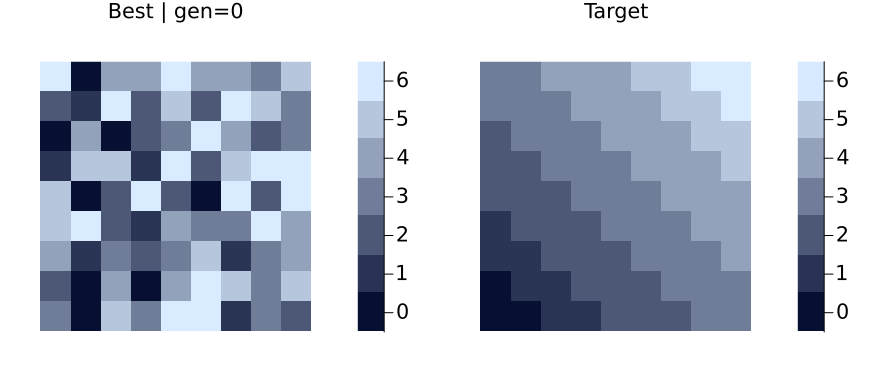

┌ Info: done
│   N = 9
│   metric = :euclid
│   crossover = :uniform_genes
│   best = 4.58257569495584
│   gen = 650
│   stop = "max_generations"
└   file = "ga_N9_euclid_uniform_genes.gif"
[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N9_hamming_uniform_genes.gif


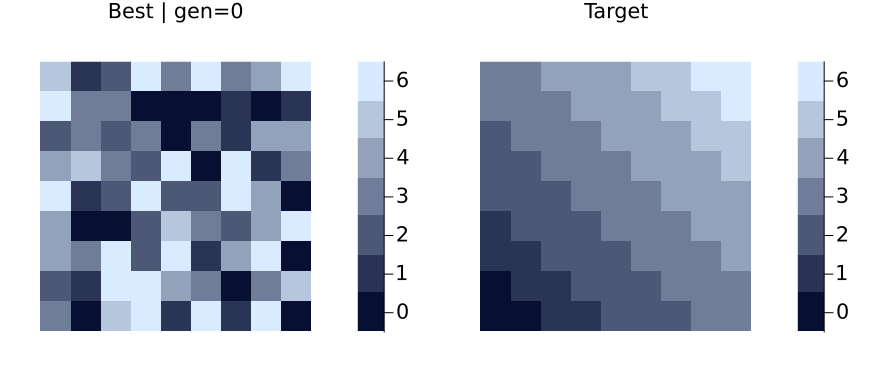

┌ Info: done
│   N = 9
│   metric = :hamming
│   crossover = :uniform_genes
│   best = 1.0
│   gen = 650
│   stop = "max_generations"
└   file = "ga_N9_hamming_uniform_genes.gif"
[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N21_euclid_uniform_genes.gif


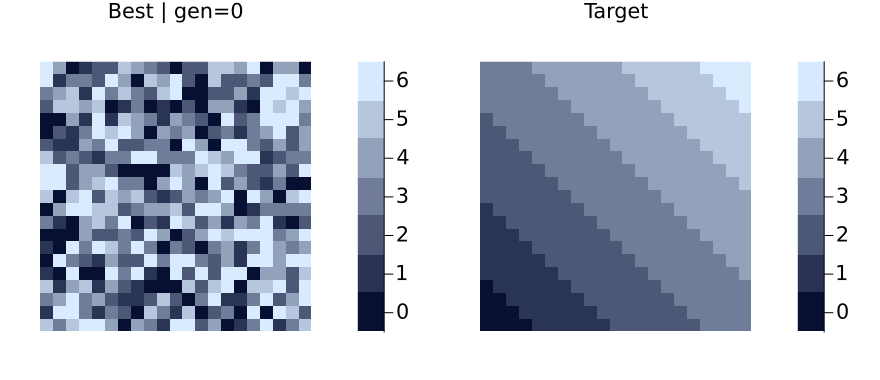

┌ Info: done
│   N = 21
│   metric = :euclid
│   crossover = :uniform_genes
│   best = 25.099800796022265
│   gen = 900
│   stop = "max_generations"
└   file = "ga_N21_euclid_uniform_genes.gif"
[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab18\ga_N21_hamming_uniform_genes.gif


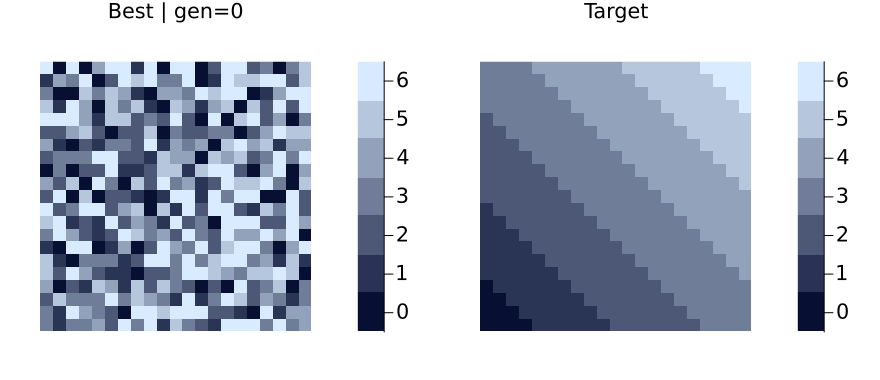

┌ Info: done
│   N = 21
│   metric = :hamming
│   crossover = :uniform_genes
│   best = 180.0
│   gen = 900
│   stop = "max_generations"
└   file = "ga_N21_hamming_uniform_genes.gif"


8

In [10]:
function run_experiments(; crossover_mode=:uniform_genes)
    Ns = [3, 5, 9, 21]
    metrics = [:euclid, :hamming]

    results = []
    for N in Ns, metric in metrics
        eps = metric == :euclid ? 1e-3 : 1.0  
        p = GAParams(population_size = N <= 9 ? 110 : 160,
                     max_generations = N <= 9 ? 650 : 900,
                     elitism = 2,
                     tournament_k = 3,
                     crossover_rate = 0.95,
                     mutation_p = N <= 9 ? 0.012 : 0.010,
                     crossover_mode = crossover_mode,
                     seed = 1)

        r = run_ga(N; metric=metric, eps=eps, params=p)
        push!(results, r)

        fname = "ga_N$(N)_$(metric)_$(crossover_mode).gif"
        make_gif(r; filename=fname, every=1, fps=10)
        @info "done" N=N metric=metric crossover=crossover_mode best=r.best_hist[end] gen=r.generations stop=r.stop_reason file=fname
    end
    return results
end

results = run_experiments(; crossover_mode=:uniform_genes)
length(results)